In [ ]:
# pip install tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
import joblib
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [3]:
# Load your exact CSV
df = pd.read_csv('master_clauses.csv')
print(f"✅ Loaded {len(df)} contracts")
print("First few column names:", list(df.columns[:10]))


✅ Loaded 510 contracts
First few column names: ['Filename', 'Document Name', 'Document Name-Answer', 'Parties', 'Parties-Answer', 'Agreement Date', 'Agreement Date-Answer', 'Effective Date', 'Effective Date-Answer', 'Expiration Date']


In [4]:
df.head()

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


In [5]:
answer_cols = [col for col in df.columns if '-Answer' in col or '- Answer' in col]
categories = [col.replace('-Answer', '').replace('- Answer', '').strip() for col in answer_cols]


In [6]:
# Auto-detect all CUAD categories from your CSV

print(f"✅ Found {len(categories)} categories")
print("Sample categories:", categories[:15])

✅ Found 41 categories
Sample categories: ['Document Name', 'Parties', 'Agreement Date', 'Effective Date', 'Expiration Date', 'Renewal Term', 'Notice Period To Terminate Renewal', 'Governing Law', 'Most Favored Nation', 'Competitive Restriction Exception', 'Non-Compete', 'Exclusivity', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Non-Disparagement']


In [7]:
records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Creating training examples"):
    for cat in categories:
        clause_col = cat
        answer_col = f"{cat}-Answer" if f"{cat}-Answer" in df.columns else f"{cat}- Answer"
        
        if clause_col in row and answer_col in row:
            clause_text = str(row[clause_col]).strip()
            answer_str = str(row[answer_col]).strip().lower()
            
            label = 1 if any(word in answer_str for word in ['yes', 'true', '1']) else 0
            
            if len(clause_text) > 20:   # ignore empty or very short clauses
                records.append({
                    'contract': row['Filename'],
                    'category': cat,
                    'clause_text': clause_text,
                    'label': label
                })

Creating training examples:   0%|          | 0/510 [00:00<?, ?it/s]

Creating training examples: 100%|██████████| 510/510 [00:02<00:00, 193.97it/s]


In [8]:
train_df = pd.DataFrame(records)
print(f"\n✅ Final training dataset: {len(train_df):,} examples")
print(train_df['label'].value_counts())



✅ Final training dataset: 6,298 examples
label
1    4430
0    1868
Name: count, dtype: int64


In [9]:
X = train_df['clause_text']
y = train_df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2), stop_words='english')

In [12]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [13]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [14]:
train_df.head()

,contract,category,clause_text,label
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Document Name,['MARKETING AFFILIATE AGREEMENT'],0
1,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Parties,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...",0
2,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Agreement Date,"['8th day of May 2014', 'May 8, 2014']",1
3,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Effective Date,['This agreement shall begin upon the date of ...,0
4,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Expiration Date,['This agreement shall begin upon the date of ...,1


In [15]:
y_pred = model.predict(X_test_vec)

In [16]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"\nOverall Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Overall F1 Score : {f1_score(y_test, y_pred):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       374
           1       0.96      0.92      0.94       886

    accuracy                           0.92      1260
   macro avg       0.89      0.91      0.90      1260
weighted avg       0.92      0.92      0.92      1260


Overall Accuracy : 0.9151
Overall F1 Score : 0.9385


In [17]:
joblib.dump(model, 'cuad_clause_classifier.pkl')
joblib.dump(vectorizer, 'cuad_tfidf_vectorizer.pkl')
train_df.to_csv('cuad_training_data.csv', index=False)

C:\Users\PRIYANKA\AppData\Local\Temp\ipykernel_20608\3797844587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cats.index, x=top_cats.values, palette="viridis")


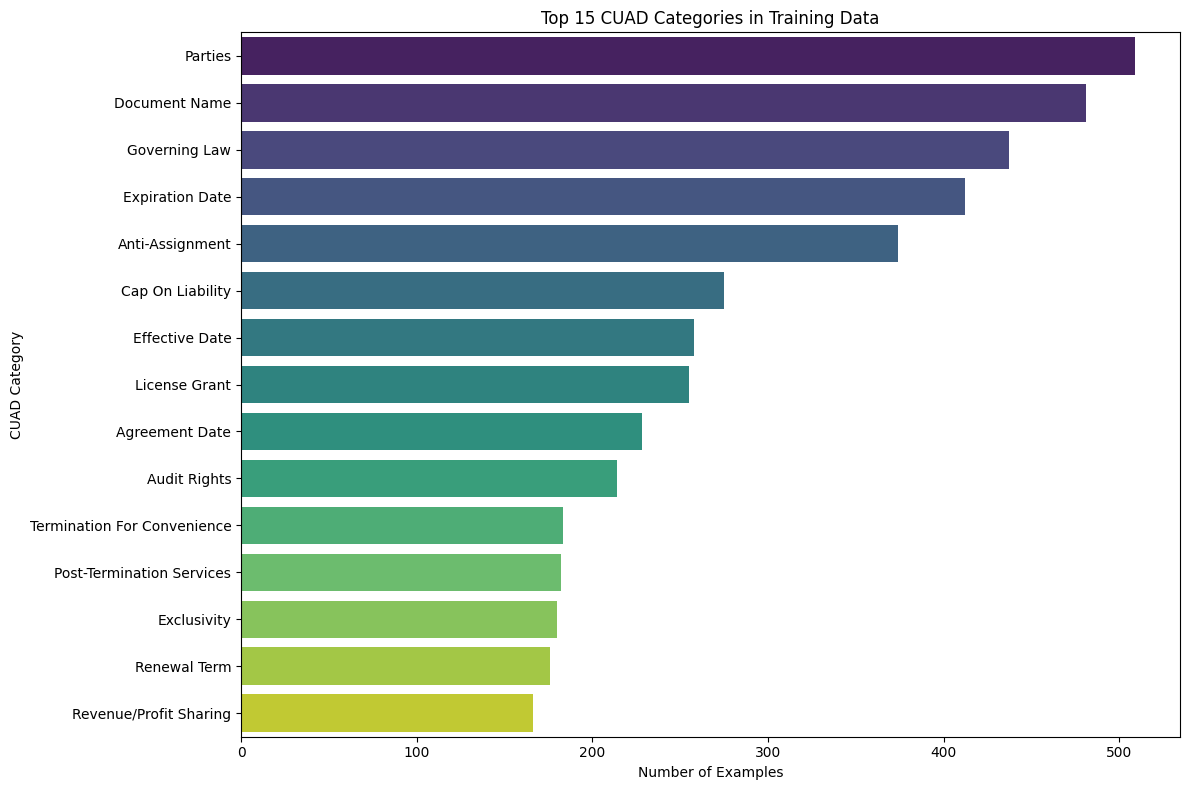

In [18]:
plt.figure(figsize=(12, 8))
top_cats = train_df['category'].value_counts().head(15)
sns.barplot(y=top_cats.index, x=top_cats.values, palette="viridis")
plt.title('Top 15 CUAD Categories in Training Data')
plt.xlabel('Number of Examples')
plt.ylabel('CUAD Category')
plt.tight_layout()
plt.show()

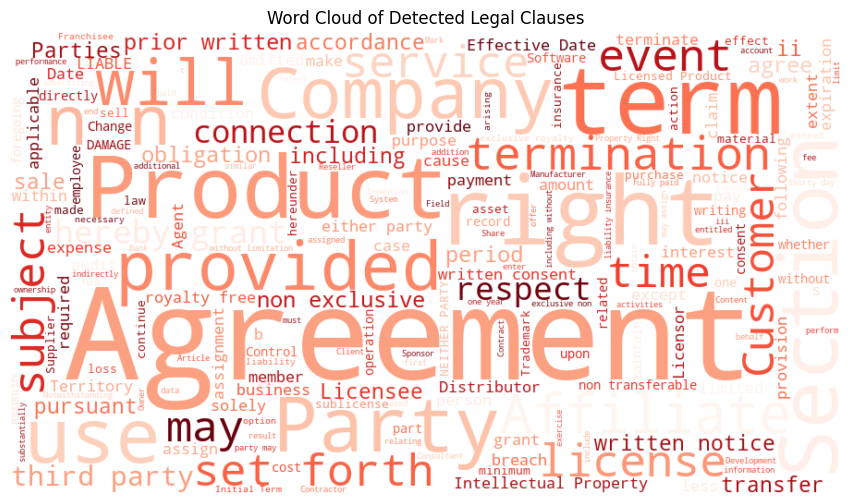

In [19]:
from wordcloud import WordCloud

high_risk_text = " ".join(train_df[train_df['label'] == 1]['clause_text'])
wordcloud = WordCloud(width=900, height=500, background_color='white', colormap='Reds').generate(high_risk_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Detected Legal Clauses')
plt.show()

In [20]:
y_pred = model.predict(X_test_vec)

In [21]:
acc = f1_score(y_test, y_pred)
print(acc)

0.9384703852788959


In [22]:
print("Accuracy:", round(acc*100,2), "%")

Accuracy: 93.85 %


In [23]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"\nOverall F1 Score: {f1_score(y_test, y_pred):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       374
           1       0.96      0.92      0.94       886

    accuracy                           0.92      1260
   macro avg       0.89      0.91      0.90      1260
weighted avg       0.92      0.92      0.92      1260


Overall F1 Score: 0.9385


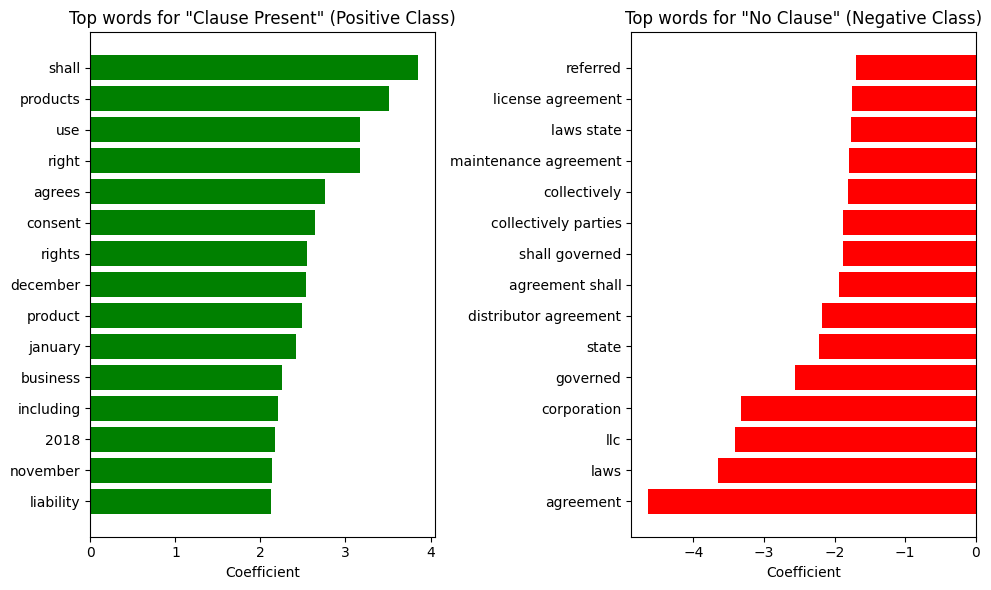

In [24]:
# Get feature importance from the model
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = np.argsort(coef)[-15:]
top_negative = np.argsort(coef)[:15]

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.barh([feature_names[i] for i in top_positive], coef[top_positive], color='green')
plt.title('Top words for "Clause Present" (Positive Class)')
plt.xlabel('Coefficient')

plt.subplot(1, 2, 2)
plt.barh([feature_names[i] for i in top_negative], coef[top_negative], color='red')
plt.title('Top words for "No Clause" (Negative Class)')
plt.xlabel('Coefficient')

plt.tight_layout()
plt.show()

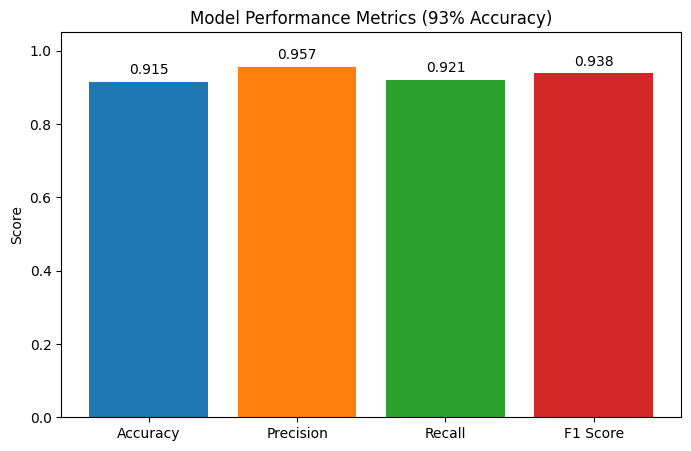

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Model Performance Metrics (93% Accuracy)')
plt.ylabel('Score')
plt.ylim(0, 1.05)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center')

plt.show()